In [120]:
import torch
import torch.nn.functional as f
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

import re
import random

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

torch.set_num_threads(1)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

Three CSV files from CNBC, Guardian, and Reuters are loaded and merged into a flat headline list. NaN entries are filtered and each string is normalized to single-space ASCII, producing 53,370 clean headlines. GPU availability is detected at load time to route all tensors to the correct device.

In [121]:
#extracting datasets
df_cnbc = pd.read_csv('Dataset/cnbc_headlines.csv')
df_guardian = pd.read_csv('Dataset/guardian_headlines.csv')
df_reuters = pd.read_csv('Dataset/reuters_headlines.csv')

#considering only headlines
headline_cnbc = list(df_cnbc['Headlines'])
headline_guardian = list(df_guardian['Headlines'])
headline_reuters = list(df_reuters['Headlines'])

#list of headlines
headline_list = headline_cnbc + headline_guardian + headline_reuters

print("No.of headlines in list: ",len(headline_list))
print(headline_list[:5])

#cleaning dataset

#filtering empty rows
headline_list = [h for h in headline_list if str(h) != 'nan']
print("No.of headlines in list: ",len(headline_list))
print(headline_list[:5])

#removing spaces in headline
def clean_headline(h):
    h = h.strip() #remove the trailing spaces from either end
    h = re.sub(r'\s+', ' ', h) #replace bigger spaces with a single space
    h = h.encode('ascii', 'ignore').decode()  # remove non-ASCII
    return h

headline_list = [clean_headline(h) for h in headline_list]

No.of headlines in list:  53650
['Jim Cramer: A better way to invest in the Covid-19 vaccine gold rush', "Cramer's lightning round: I would own Teradyne", nan, "Cramer's week ahead: Big week for earnings, even bigger week for vaccines", 'IQ Capital CEO Keith Bliss says tech and healthcare will rally']
No.of headlines in list:  53370
['Jim Cramer: A better way to invest in the Covid-19 vaccine gold rush', "Cramer's lightning round: I would own Teradyne", "Cramer's week ahead: Big week for earnings, even bigger week for vaccines", 'IQ Capital CEO Keith Bliss says tech and healthcare will rally', "Wall Street delivered the 'kind of pullback I've been waiting for,' Jim Cramer says"]


In [122]:
print(len(headline_list))

53370


All unique characters are collected into a sorted set and extended with `<S>`/`<E>` boundary tokens, fixing the vocabulary at 84 symbols. `vocab_size` is set here because every WaveNet layer dimension — embedding width, hidden size, and output projection — is parameterized from this single value.

In [123]:
#vocabulary set
unique_words = set()

for headline in headline_list:
    for letter in list(headline):
        unique_words.add(letter)
    
unique_words = ['<S>', '<E>'] + sorted(unique_words)
vocab_size = len(unique_words)
print("Vocabulary size: ",vocab_size)

#number to word matrix
num2letter_dict = {i:letter for i, letter in enumerate(unique_words)}

#word to number matrix
letter2num_dict = {letter:i for i, letter in enumerate(unique_words)}


Vocabulary size:  84


Headlines are shuffled with a fixed seed and split 80/10/10 into train, validation, and test sets. `block_size` is extended to 8 here — three `FlattenConsecutive(2)` layers each halve the sequence length, so exactly 8 input tokens are required for the hierarchy to collapse to a single vector.

In [124]:
#building the dataset
block_size = 8

def build_dataset(headline_list):
    context_x = [] #list of all context windows
    targets_y = [] #list of all targets
    for chs in headline_list:
        context_window = [0]*block_size
        for ch in list(chs) + ['<E>']:
            idx = letter2num_dict[ch]
            context_x.append(context_window)
            targets_y.append(idx)
            context_window = context_window[1:] + [idx] #slide context window
        
    #convert the list of context windows and targets into tensors
    context_x = torch.tensor(context_x)
    targets_y = torch.tensor(targets_y)
    return context_x, targets_y

random.seed(42)
random.shuffle(headline_list)
n1 = int(0.8*len(headline_list)) #-> 80% of headline_list
n2 = int(0.9*len(headline_list)) #-> 90% of headline_list

#splitting into train, validation and test datasets
Xtr, Ytr = build_dataset(headline_list[:n1]) #-> 80%
Xval, Yval = build_dataset(headline_list[n1:n2]) #-> 10%
Xtest, Ytest = build_dataset(headline_list[n2:]) #->10%

In [125]:
for x,y in zip(Xtr[:20], Ytr[:20]):
    print(' '.join(num2letter_dict[ix.item()] for ix in x), '==>', num2letter_dict[y.item()])

<S> <S> <S> <S> <S> <S> <S> <S> ==> T
<S> <S> <S> <S> <S> <S> <S> T ==> w
<S> <S> <S> <S> <S> <S> T w ==> o
<S> <S> <S> <S> <S> T w o ==>  
<S> <S> <S> <S> T w o   ==> H
<S> <S> <S> T w o   H ==> u
<S> <S> T w o   H u ==> a
<S> T w o   H u a ==> w
T w o   H u a w ==> e
w o   H u a w e ==> i
o   H u a w e i ==>  
  H u a w e i   ==> s
H u a w e i   s ==> t
u a w e i   s t ==> a
a w e i   s t a ==> f
w e i   s t a f ==> f
e i   s t a f f ==>  
i   s t a f f   ==> e
  s t a f f   e ==> x
s t a f f   e x ==> p


# Python Classes in this MLP — What each method does

## `__init__`
The constructor. Runs **once** when you create the object. Sets up all internal variables (weights, biases, parameters). Think of it as "building the layer before using it."
```python
layer = Linear(30, 200)  # __init__ runs here
```

## `__call__`
Runs when you "call" the object like a function. This is the **forward pass** — takes input `x`, does the computation, returns output.
```python
out = layer(x)  # __call__ runs here
```
Without `__call__`, you'd have to write `layer.forward(x)` every time. `__call__` lets you treat the layer like a function.

## `parameters()`
Returns a list of all tensors that need to be updated by gradient descent. The training loop calls this on every layer to collect all learnable weights in one place:
```python
parameters = []
for layer in layers:
    parameters += layer.parameters()
# now update all of them in one loop
```
Only learnable tensors go here — NOT running stats like `running_mean`/`running_var` in batchnorm, since those aren't updated by gradients.


In [126]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out))/fan_in**0.5 #KAIMING NORMALIZATION
        self.bias = torch.randn(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight #linear equation
        if self.bias is not None:
            self.out += self.bias #check for bias and add
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias]) #array of weights

In [127]:
class BatchNorm1d:
    def __init__(self, dim, epsilon=1e-5, momentum=0.1):
        self.epsilon = epsilon #(epsilon) prevents zero division in norm
        self.momentum = momentum #how fast running stats updates (running_mean and batchnorm mean) during inference
        self.training = True #flag b/w training and inference states
        #--parameters (trained in backprop)--
        self.gamma = torch.ones(dim) #bngain
        self.beta = torch.zeros(dim) #bnbias
        #--buffers (trained with a running "momentum" update)--
        self.running_mean = torch.zeros(dim) #tracks mean across batches for inference
        self.running_var = torch.ones(dim) #tracks variance across batches for inference
        #note : inference -> test/validation set

    def __call__(self, x):
        #calculate forward pass
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0,1)
            xmean = x.mean(dim, keepdim=True)
            xvar = x.var(dim, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x-xmean)/torch.sqrt(xvar + self.epsilon) #batchnorm formula : (x-mu)/sqrt(variance(x) + epsilon)
        self.out = self.gamma * xhat + self.beta #scale and shift (batchnorm formula)
        #update the inference buffers
        if self.training: 
            with torch.no_grad(): #to ensure running mean and running variance are updated without affecting the training parameters
                self.running_mean = (1-self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1-self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]

In [128]:
class Tanh:
    def __call__(self,x):
        self.out = torch.tanh(x) #tanh to squash values b/w -1 and 1
        return self.out
    def parameters(self):
        return []
    
class Embedding:
    def __init__(self, num_embeddings, embedding_dim): #usually (vocab_size, num_of_embeddings)
        self.weight = torch.randn((num_embeddings, embedding_dim))
        #num_embeddings => num of characters in vocabulary (84 here)
        #embedding_dim => size of embedding vector (10 here)
        #therefore, => torch.randn((84,10)) => same as C matrix

    def __call__(self, IX):
        self.out = self.weight[IX] #embedding lookup (C[Xb], referencing to previous MLP codes)
        return self.out
    
    def parameters(self):
        return [self.weight]
    
class FlattenConsecutive:
    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        n = self.n
        x = x.view(B, T//n, C*n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []

In [129]:
class Sequential: #class defining the neural network architecture
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x) #calls each run of list of operation belonging to the layer array [Linear (hidden layer), BatchNorm1d, Tanh, Linear (output layer)]
        self.out = x
        return self.out
    
    #get parameters of all layers and stretch them out into one list
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    

The WaveNet model is assembled as a `Sequential` over three `FlattenConsecutive(2)` + Linear + BatchNorm1d + Tanh stages, each halving the sequence length while doubling channel width. In log₂(8)=3 steps the 8-token context collapses to a 128-dimensional vector before the final linear projection to 84 logits.

In [130]:
torch.manual_seed(42)

n_embd = 24 #char embedding vector dim
n_hidden = 128 #no. of expected outputs in hidden layer

#model building (Sequential(self, layers))
model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(), 
    FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),    
    FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),  
    Linear(n_hidden, vocab_size)
    ])

with torch.no_grad():
    model.layers[-1].weight *= 0.1 #normalising vectors to get minimal loss

parameters = model.parameters()
print("Total trainable parameters: ", sum(p.nelement() for p in parameters)) #p.nelement() -> no of elements in that tensor
#the print shows the total trainable parameters in network

#enable gradients (backpropagation)
for p in parameters:
    p.requires_grad = True

Total trainable parameters:  85300


In [131]:
#moving variables to cuda
for p in parameters:
    p.data = p.data.to(device)
#parameters contain W1, W2, b2, bngain, bnbias etc.
#hence moving parameters to device, moves all these variables too

Xtr = Xtr.to(device)
Ytr = Ytr.to(device)
Xval = Xval.to(device)
Yval = Yval.to(device)
Xtest = Xtest.to(device)
Ytest = Ytest.to(device)

for layer in model.layers:
    if isinstance(layer, BatchNorm1d):
        layer.running_mean = layer.running_mean.to(device)
        layer.running_var = layer.running_var.to(device)

In [132]:
#consdering a batch of 4 examples to recheck sizes
# (4, 200) @ (200, 84) = (4, 84) => final layer computation for reference
ix = torch.randint(0, Xtr.shape[0], (4,)) #randint(low, high, size)
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
print(Xb)

#model sizes:
for layer in model.layers:
    print(layer.__class__.__name__, ":", tuple(layer.out.shape))

torch.Size([4, 8])
tensor([[49, 73, 62, 71, 60, 62, 75,  2],
        [28,  2, 60, 72, 70, 73, 58, 71],
        [16, 25,  2, 59, 66, 69, 69, 66],
        [ 2, 59, 62,  2, 76, 62, 80, 71]], device='cuda:0')
Embedding : (4, 8, 24)
FlattenConsecutive : (4, 4, 48)
Linear : (4, 4, 128)
BatchNorm1d : (4, 4, 128)
Tanh : (4, 4, 128)
FlattenConsecutive : (4, 2, 256)
Linear : (4, 2, 128)
BatchNorm1d : (4, 2, 128)
Tanh : (4, 2, 128)
FlattenConsecutive : (4, 256)
Linear : (4, 128)
BatchNorm1d : (4, 128)
Tanh : (4, 128)
Linear : (4, 84)


Mini-batches of 256 samples are passed through the full `Sequential` model with a single `model(Xb)` call — each layer's `__call__` fires in order, handling embedding lookup, consecutive token folding, linear projections, BatchNorm, and Tanh. The learning rate decays from 0.1 to 0.01 after step 150,000.

In [133]:
#training loop
max_steps = 200000
batch_size = 256
lossi = []

for i in range(max_steps):
    #minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    #forward pass
    logits = model(Xb) #running the model to execute every operation defined in each layer
    loss = f.cross_entropy(logits, Yb)

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #gradient descent
    lr = 0.1 if i<150000 else 0.01 #to stop learning rate decay
    for p in parameters:
        p.data += -lr*p.grad
    
    #tracking
    if i%10000 == 0:
        print("Iteration "+f'{i}'+": "+f'{loss.item()}')
    lossi.append(loss.detach().cpu().log10().item())

torch.cuda.empty_cache() 
print("Training complete")

Iteration 0: 4.899193286895752
Iteration 10000: 1.876086950302124
Iteration 20000: 1.6337480545043945
Iteration 30000: 1.4694337844848633
Iteration 40000: 1.5795321464538574
Iteration 50000: 1.489863395690918
Iteration 60000: 1.5010714530944824
Iteration 70000: 1.4534727334976196
Iteration 80000: 1.4754915237426758
Iteration 90000: 1.4724531173706055
Iteration 100000: 1.5088951587677002
Iteration 110000: 1.5819189548492432
Iteration 120000: 1.5086400508880615
Iteration 130000: 1.5387485027313232
Iteration 140000: 1.4744431972503662
Iteration 150000: 1.3376045227050781
Iteration 160000: 1.4766101837158203
Iteration 170000: 1.373331069946289
Iteration 180000: 1.3278659582138062
Iteration 190000: 1.4772109985351562
Training complete


In [134]:
for layer in model.layers:
    print(layer.__class__.__name__, ":", tuple(layer.out.shape))

Embedding : (256, 8, 24)
FlattenConsecutive : (256, 4, 48)
Linear : (256, 4, 128)
BatchNorm1d : (256, 4, 128)
Tanh : (256, 4, 128)
FlattenConsecutive : (256, 2, 256)
Linear : (256, 2, 128)
BatchNorm1d : (256, 2, 128)
Tanh : (256, 2, 128)
FlattenConsecutive : (256, 256)
Linear : (256, 128)
BatchNorm1d : (256, 128)
Tanh : (256, 128)
Linear : (256, 84)


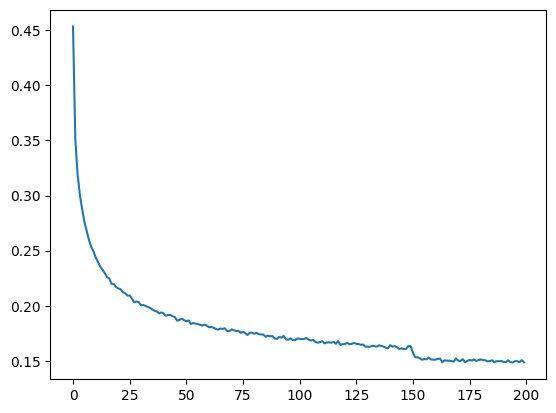

In [135]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [136]:
#now, sending the layers to "eval" mode
for layer in model.layers:
    layer.training = False

`split_loss` sets all BatchNorm layers to eval mode and processes each split in 1,000-sample chunks to stay within GPU memory, accumulating per-chunk losses before averaging. Eval mode is required so running statistics are used rather than unstable batch statistics from small chunks.

In [137]:
@torch.no_grad() #decorator : disables gradient tracking
def split_loss(split):
    XXb,YYb = {
        'train': (Xtr, Ytr),
        'val': (Xval, Yval),
        'test': (Xtest, Ytest)
    }[split]

    #processing in batches and accumulating losses
    losses = []

    ##processing X and Y in batches as GPU memory isn't enough
    for i in range(0, XXb.shape[0], 1000):
        Xbatch = XXb[i:i+1000] 
        Ybatch = YYb[i:i+1000]
        #forward pass
        logits=model(Xbatch)
        loss=f.cross_entropy(logits, Ybatch)
        losses.append(loss.item())
    print(split, sum(losses)/len(losses)) #avg loss obtained in training set
        

split_loss('train')
split_loss('val')


train 1.3975802661233192
val 1.4251337870539234


The generator maintains an 8-character sliding context window, passing the full window through the WaveNet stack and sampling the next character from the resulting softmax distribution. The window advances one position per step until `<E>` is drawn, yielding the complete headline.

In [138]:
#GENERATOR CODE:
def generate_headline():
    create_headline = []
    context_window = [0] * block_size
    while True:
        #forward pass
        logits = model(torch.tensor([context_window])) #passing a tensor input into the model
        y_pred = f.softmax(logits, dim=1)

        idx = torch.multinomial(y_pred, 1) #sample from distrubution

        #if char = '<E>', break the loop
        if num2letter_dict[idx.item()] == '<E>':
            break

        create_headline.append(num2letter_dict[idx.item()]) #converting index to character and appending it
        context_window = context_window[1:] + [idx.item()] #moving the context window

    return ''.join(create_headline)


for i in range(10):
    print(f'Headline {i+1}: ', generate_headline())


Headline 1:  Lockheed?
Headline 2:  Frenzures investinies asked to blockdowns over management'' down in 30 untilitics, and Elady firms Bristore to US-China drive count U.S. survey
Headline 3:  Repkart sells $5.8 20-billion on divedbound in 2018: Keying for stimulus says trade for the UK
Headline 4:  Facebook,, crising it's croate major condrewn
Headline 5:  Books Airlive Chinese loss
Headline 6:  Cramer's lightnt push
Headline 7:  Trump rejecteer talks in heavying targets as Amazon, seeding UV carks in?G grouters to conserve
Headline 8:  Unilers forecast allege to U.S. off,,000 as trade ban
Headline 9:  EasyJet' world strope gains tax industry
Headline 10:  U.S. hift over heair says he administrator increase case


In [139]:
#AN EXAMPLE TO VISUALISE THE CALCULATION BEHIND THE MEAN/VARIANCE IN BATCHNORM                                                     

data = torch.tensor([[[1,2,3,4],[5,6,7,8]],[[1,2,3,4],[5,6,7,8]]]).float()
print(data.shape)

dm = data.mean(0, keepdim=True)
print(dm)
print(dm.shape)
dm2 = data.mean((0,1), keepdim=True)
print(dm2)
print(dm2.shape)
dm3 = data.mean((0,2), keepdim=True)
print(dm3)
print(dm3.shape)
dm

torch.Size([2, 2, 4])
tensor([[[1., 2., 3., 4.],
         [5., 6., 7., 8.]]])
torch.Size([1, 2, 4])
tensor([[[3., 4., 5., 6.]]])
torch.Size([1, 1, 4])
tensor([[[2.5000],
         [6.5000]]])
torch.Size([1, 2, 1])


tensor([[[1., 2., 3., 4.],
         [5., 6., 7., 8.]]])